# Figure 3: Runtime Performance and Memory Scalability

Core performance benchmark figure.

| Panel | Content |
|---|---|
| **3A** | CrossCell time vs nnz (scatter + linear fit) |
| **3B** | Speedup distribution (box + jitter) |
| **3C** | Memory vs nnz (multi-tool scatter) |
| **3D** | Large dataset spotlight (grouped bar) |

**Data source**: `robustness_benchmark.json`.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import json, os, re, subprocess, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path('/benchmark/results')
DATA_DIR = Path('/benchmark/data/generated')
FIGURES_DIR_MAIN = Path('/benchmark/figures/main')
FIGURES_DIR_SUPP = Path('/benchmark/figures/supplementary')
TMP_DIR = Path('/tmp/notebook_work')

for d in [RESULTS_DIR, FIGURES_DIR_MAIN, FIGURES_DIR_SUPP, TMP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 10, 'axes.labelsize': 11,
    'axes.titlesize': 12, 'figure.dpi': 150,
    'savefig.dpi': 300, 'savefig.bbox': 'tight',
})

COLORS = {
    'CrossCell': '#025e8d', 'Zellkonverter': '#f58220',
    'anndataR': '#00a69d', 'convert2anndata': '#785ba7',
    'easySCF': '#c75301',
    'success': '#00a69d', 'failed': '#be1818', 'na': '#999999',
}

ALL_TOOLS = ['CrossCell', 'Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']

def extract_error_reason(stderr_text):
    """Extract a short error reason from R/tool stderr output."""
    if not stderr_text:
        return 'unknown error'
    for line in stderr_text.split('\n'):
        line = line.strip()
        if line.startswith('Error') or 'error' in line.lower():
            return line[:120] + ('...' if len(line) > 120 else '')
    lines = [l.strip() for l in stderr_text.strip().split('\n') if l.strip()]
    if lines:
        return lines[-1][:120]
    return 'unknown error'

from scipy import stats

FIGURES_DIR = FIGURES_DIR_MAIN
FIG3_FILE = RESULTS_DIR / 'robustness_benchmark.json'
CONFIG_DIR = Path('/benchmark/config')
TESTCASES_FILE = CONFIG_DIR / 'benchmark_testcases.json'

if not FIG3_FILE.exists():
    raise FileNotFoundError(
        f'{FIG3_FILE} not found. Run fig3_robustness.ipynb first to generate benchmark data.'
    )

with open(FIG3_FILE) as f:
    bench = json.load(f)
print(f'✅ Loaded results from {FIG3_FILE}')

if TESTCASES_FILE.exists():
    with open(TESTCASES_FILE) as f:
        testcases = json.load(f)

print('✅ Environment setup complete')


✅ Loaded results from /benchmark/results/robustness_benchmark.json
✅ Environment setup complete


## 1. Load and Prepare Data

In [2]:

# Flatten nested structure (handle both old and new JSON formats)
flat_bench = {}
for key, val in bench.items():
    if isinstance(val, dict) and any(d in val for d in ['rds_to_h5ad', 'h5ad_to_rds']):
        flat_bench[key] = val
    elif isinstance(val, dict):
        for sub_key, sub_val in val.items():
            if isinstance(sub_val, dict):
                flat_bench[sub_key] = sub_val

# Extract all tool results
tool_dfs = {}
for tool_key in ['crosscell', 'zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']:
    records = []
    for direction in ['rds_to_h5ad', 'h5ad_to_rds']:
        for r in flat_bench.get(tool_key, {}).get(direction, []):
            r['direction'] = direction
            records.append(r)
    if records:
        tool_name = {'crosscell': 'CrossCell', 'zellkonverter': 'Zellkonverter',
                     'anndataR': 'anndataR', 'convert2anndata': 'convert2anndata',
                     'easySCF': 'easySCF'}[tool_key]
        tool_dfs[tool_name] = pd.DataFrame(records)
        n_ok = (tool_dfs[tool_name]['status'] == 'success').sum()
        print(f'{tool_name}: {n_ok}/{len(records)} success')

assert 'CrossCell' in tool_dfs, (
    'No benchmark data found. Run fig3_robustness.ipynb first '
    'to generate robustness_benchmark.json, then re-run this notebook.'
)
cc = tool_dfs['CrossCell']
cc_r2h = cc[(cc['direction'] == 'rds_to_h5ad') & (cc['status'] == 'success')].copy()
print(f'\nCrossCell RDS→H5AD: {len(cc_r2h)} successful tests')


CrossCell: 55/55 success
Zellkonverter: 54/55 success
anndataR: 42/55 success
convert2anndata: 19/42 success
easySCF: 42/55 success

CrossCell RDS→H5AD: 42 successful tests


## 2. Fig 3A: Time vs nnz (CrossCell)

Saved fig3a


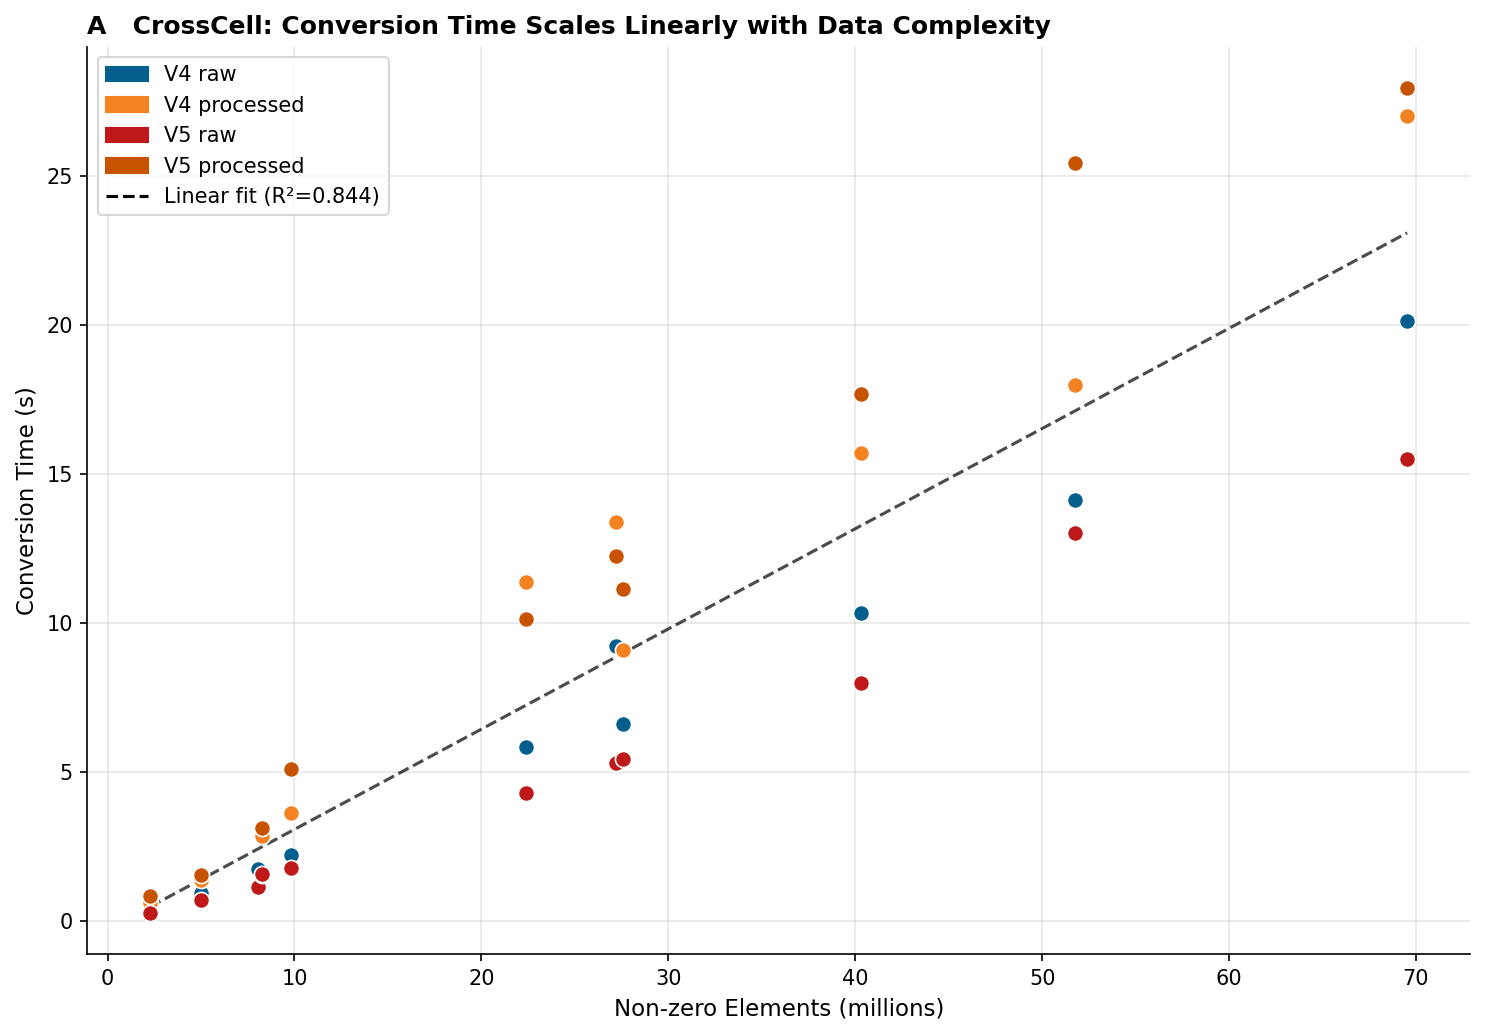

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))

# Color by category
cat_colors = {'V4 raw': '#025e8d', 'V4 processed': '#f58220',
              'V5 raw': '#be1818', 'V5 processed': '#c75301'}

for _, row in cc_r2h.iterrows():
    cat = f'{row.get("seurat_version", "V5")} {row.get("type", "raw")}'
    color = cat_colors.get(cat, '#999')
    ax.scatter(row['nnz'] / 1e6,
               row['conversion_time_seconds'], s=60, c=color, edgecolor='white',
               linewidth=0.8, zorder=3)

x_vals = (cc_r2h['nnz'] / 1e6).values
y_vals = cc_r2h['conversion_time_seconds'].values
slope, intercept, r_value, _, _ = stats.linregress(x_vals, y_vals)
x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(x_fit, slope * x_fit + intercept, 'k--', linewidth=1.5, alpha=0.7,
        label=f'R\u00b2 = {r_value**2:.3f}')

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=c, label=l) for l, c in cat_colors.items()]
patches.append(plt.Line2D([0],[0], color='k', linestyle='--', label=f'Linear fit (R\u00b2={r_value**2:.3f})'))
ax.legend(handles=patches, loc='upper left')
ax.set_xlabel('Non-zero Elements (millions)')
ax.set_ylabel('Conversion Time (s)')
ax.set_title('A   CrossCell: Conversion Time Scales Linearly with Data Complexity', fontweight='bold', loc='left')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig3a_time_vs_nnz.pdf')
fig.savefig(FIGURES_DIR / 'fig3a_time_vs_nnz.png')
print('Saved fig3a')
plt.show()


## 3. Fig 3B: Speedup Distribution

Saved fig3b


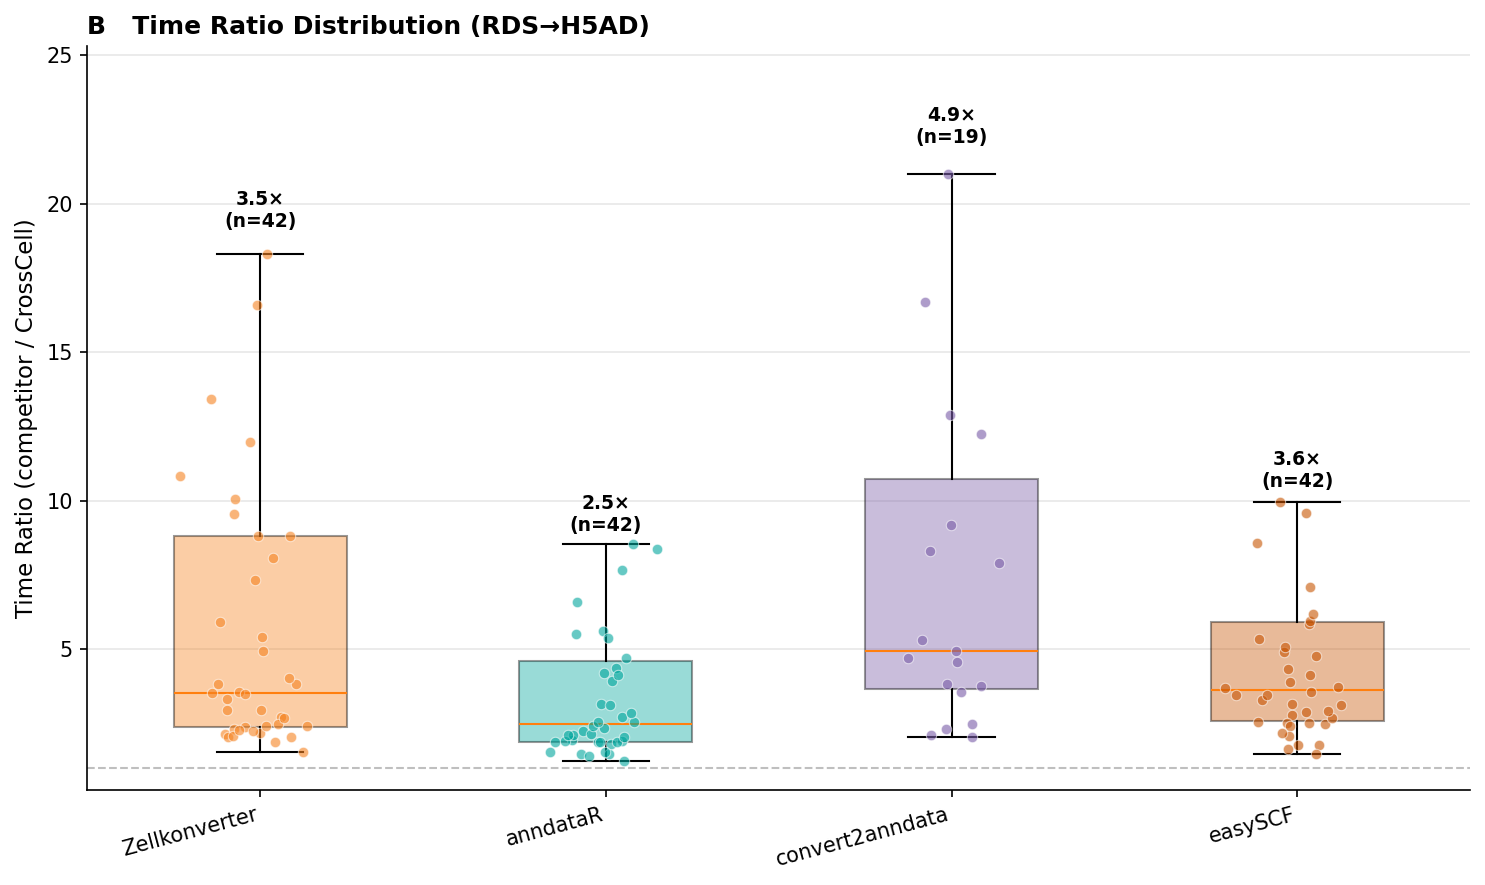

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

competitors = ['Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']
speedup_data = []
medians = []

for tool in competitors:
    if tool not in tool_dfs: continue
    df_t = tool_dfs[tool]
    df_t_r2h = df_t[(df_t['direction'] == 'rds_to_h5ad') & (df_t['status'] == 'success')]
    merged = cc_r2h.merge(df_t_r2h[['test_id', 'conversion_time_seconds']],
                          on='test_id', suffixes=('_cc', '_other'), how='inner')
    if len(merged) > 0:
        sp = merged['conversion_time_seconds_other'] / merged['conversion_time_seconds_cc']
        speedup_data.append(sp.values)
        medians.append((tool, sp.median(), len(merged)))
    else:
        speedup_data.append([])
        medians.append((tool, 0, 0))

positions = np.arange(len(competitors))
bp = ax.boxplot([s for s in speedup_data], positions=positions, widths=0.5,
                patch_artist=True, showfliers=False)

for i, (patch, tool) in enumerate(zip(bp['boxes'], competitors)):
    color = COLORS.get(tool, '#999')
    patch.set_facecolor(color)
    patch.set_alpha(0.4)
    # Jitter — only draw points within whisker range (no outliers)
    if len(speedup_data[i]) > 0:
        whisker_lo = bp['whiskers'][2 * i].get_ydata()[1]
        whisker_hi = bp['whiskers'][2 * i + 1].get_ydata()[1]
        mask = (speedup_data[i] >= whisker_lo) & (speedup_data[i] <= whisker_hi)
        pts = speedup_data[i][mask]
        jitter = np.random.normal(0, 0.08, len(pts))
        ax.scatter(positions[i] + jitter, pts, s=25, c=color,
                   alpha=0.6, edgecolor='white', linewidth=0.5, zorder=3)

ax.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xticks(positions)
ax.set_xticklabels(competitors, rotation=15, ha='right')
ax.set_ylabel('Time Ratio (competitor / CrossCell)')

for tool, med, n in medians:
    idx = competitors.index(tool)
    if med > 0 and len(speedup_data[idx]) > 0:
        whisker_hi = bp['whiskers'][2 * idx + 1].get_ydata()[1]
        ax.text(idx, whisker_hi * 1.05, f'{med:.1f}×\n(n={n})',
                ha='center', fontsize=9, fontweight='bold')

ax.set_title('B   Time Ratio Distribution (RDS\u2192H5AD)', fontweight='bold', loc='left')
# Add top margin so annotations don't overlap title
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 1.15)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig3b_speedup.pdf')
fig.savefig(FIGURES_DIR / 'fig3b_speedup.png')
print('Saved fig3b')
plt.show()


## 4. Fig 3C: Memory vs nnz

Saved fig3c


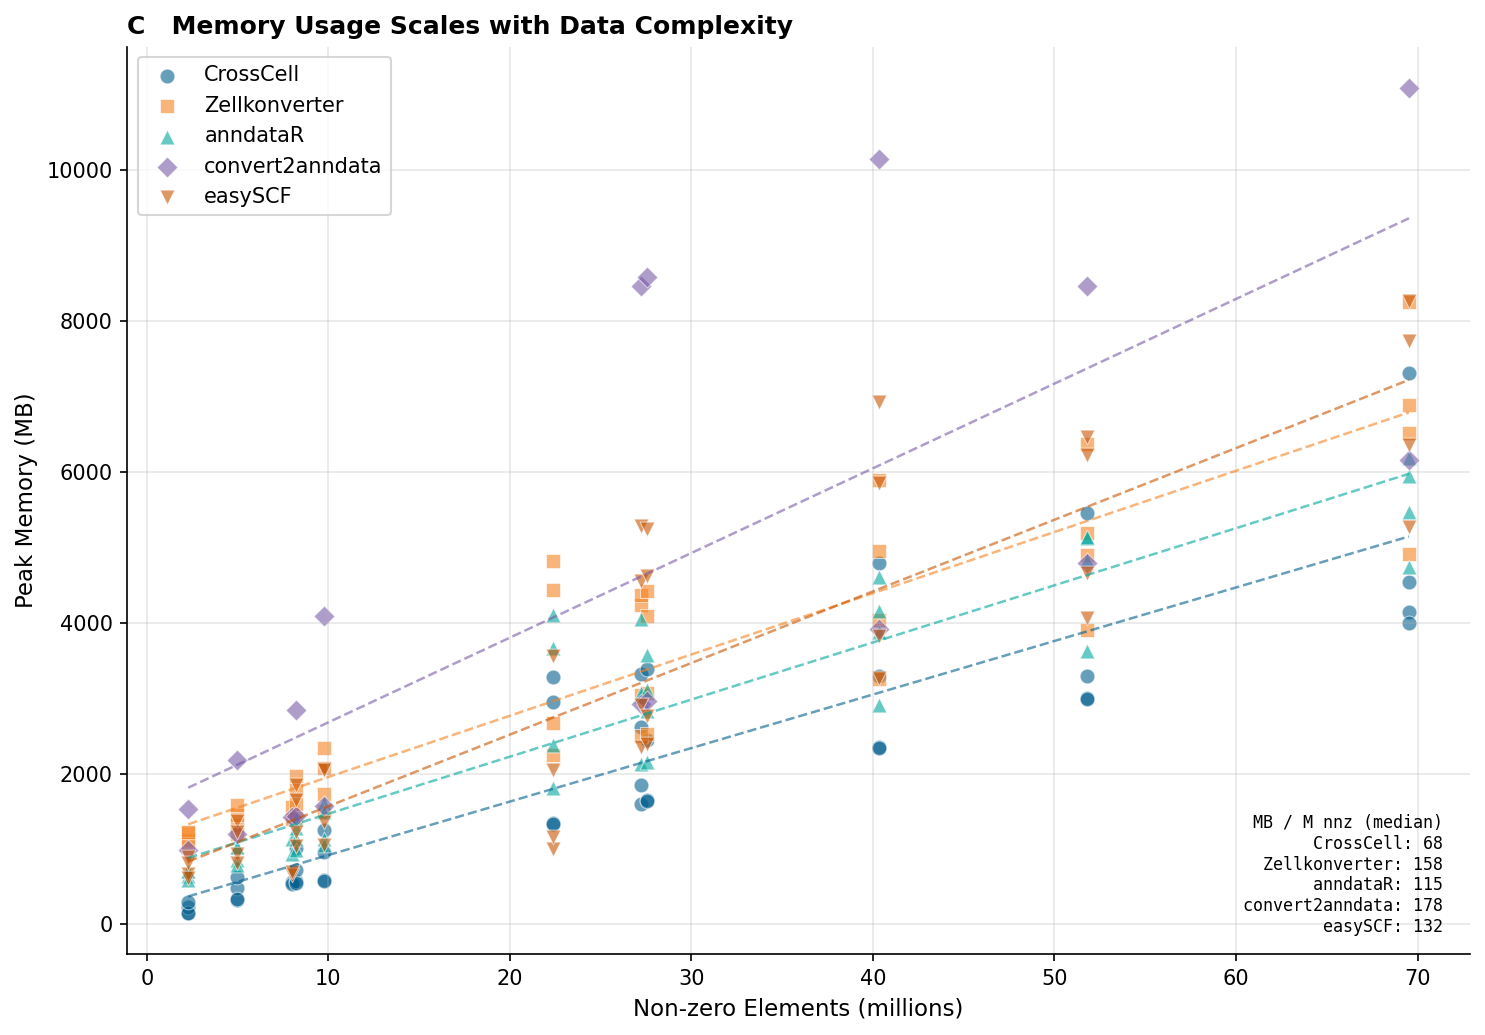

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

markers = {'CrossCell': 'o', 'Zellkonverter': 's', 'anndataR': '^',
           'convert2anndata': 'D', 'easySCF': 'v'}

for tool_name, df_t in tool_dfs.items():
    df_ok = df_t[(df_t['direction'] == 'rds_to_h5ad') & (df_t['status'] == 'success')]
    if len(df_ok) == 0 or 'peak_memory_mb' not in df_ok.columns or 'nnz' not in df_ok.columns:
        continue
    x = df_ok['nnz'] / 1e6
    y = df_ok['peak_memory_mb']
    color = COLORS.get(tool_name, '#999')
    ax.scatter(x, y, s=50, alpha=0.6,
               color=color, marker=markers.get(tool_name, 'o'),
               label=tool_name, edgecolor='white', linewidth=0.5)
    # Linear fit line
    if len(x) >= 3:
        slope, intercept, r_val, _, _ = stats.linregress(x.values, y.values)
        x_fit = np.linspace(x.min(), x.max(), 50)
        ax.plot(x_fit, slope * x_fit + intercept, color=color, linestyle='--',
                linewidth=1.2, alpha=0.6)


# Annotate memory efficiency (MB per million nnz)
eff_lines = []
for tool_name2, df_t2 in tool_dfs.items():
    df_ok2 = df_t2[(df_t2['direction'] == 'rds_to_h5ad') & (df_t2['status'] == 'success')]
    if len(df_ok2) == 0 or 'peak_memory_mb' not in df_ok2.columns or 'nnz' not in df_ok2.columns:
        continue
    eff = df_ok2['peak_memory_mb'] / (df_ok2['nnz'] / 1e6)
    eff_lines.append(f"{tool_name2}: {eff.median():.0f}")
eff_text = "MB / M nnz (median)\n" + "\n".join(eff_lines)
ax.text(0.98, 0.02, eff_text, transform=ax.transAxes,
        fontsize=8, ha='right', va='bottom', family='monospace')

ax.set_xlabel('Non-zero Elements (millions)')
ax.set_ylabel('Peak Memory (MB)')
ax.set_title('C   Memory Usage Scales with Data Complexity', fontweight='bold', loc='left')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig3c_memory_vs_nnz.pdf')
fig.savefig(FIGURES_DIR / 'fig3c_memory_vs_nnz.png')
print('Saved fig3c')
plt.show()


## 5. Fig 3D: Large Dataset Spotlight

Saved fig3d


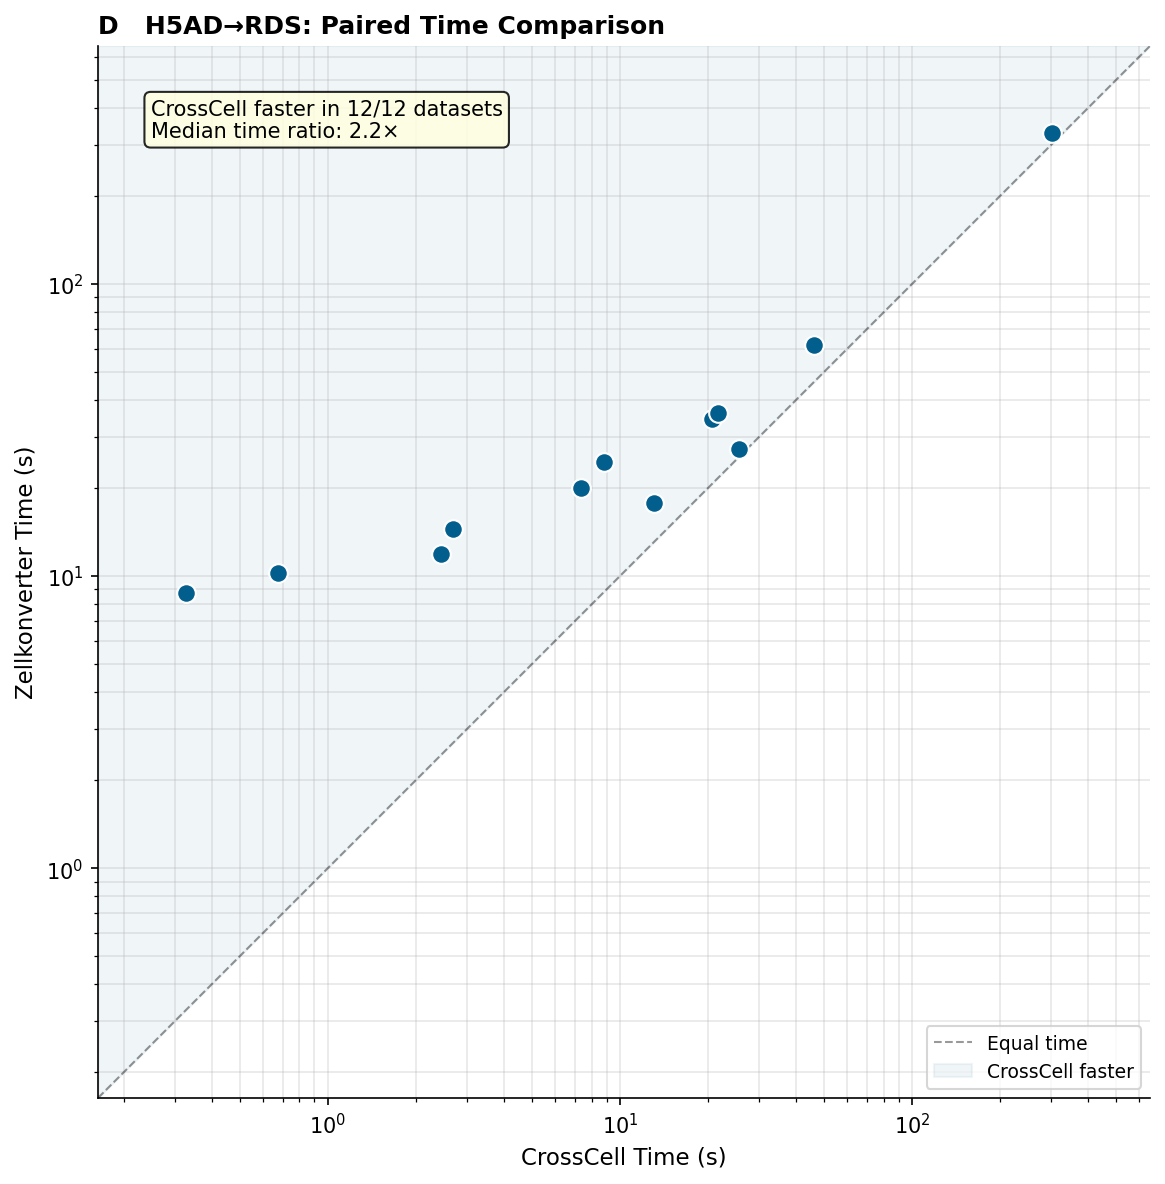

In [6]:
# ── Panel D: H5AD→RDS Paired Time Comparison (CrossCell vs Zellkonverter) ──

fig, ax = plt.subplots(figsize=(8, 8))

cc_h2r = tool_dfs['CrossCell']
cc_h2r = cc_h2r[(cc_h2r['direction'] == 'h5ad_to_rds') & (cc_h2r['status'] == 'success')].copy()

zk_h2r = tool_dfs.get('Zellkonverter', pd.DataFrame())
if len(zk_h2r) > 0:
    zk_h2r = zk_h2r[(zk_h2r['direction'] == 'h5ad_to_rds') & (zk_h2r['status'] == 'success')].copy()

merged = cc_h2r[['test_id', 'conversion_time_seconds']].merge(
    zk_h2r[['test_id', 'conversion_time_seconds']],
    on='test_id', suffixes=('_cc', '_zk'), how='inner')

ax.scatter(merged['conversion_time_seconds_cc'], merged['conversion_time_seconds_zk'],
           s=80, c='#025e8d', edgecolor='white', linewidth=1, zorder=3)

# Diagonal (equal performance)
lo = min(merged['conversion_time_seconds_cc'].min(), merged['conversion_time_seconds_zk'].min()) * 0.5
hi = max(merged['conversion_time_seconds_cc'].max(), merged['conversion_time_seconds_zk'].max()) * 2.0
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.4, label='Equal time')

# Shade "CrossCell faster" region
ax.fill_between([lo, hi], [lo, hi], [hi, hi],
                alpha=0.06, color='#025e8d', label='CrossCell faster')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect('equal')

# Summary
median_ratio = (merged['conversion_time_seconds_zk'] / merged['conversion_time_seconds_cc']).median()
n_faster = (merged['conversion_time_seconds_cc'] < merged['conversion_time_seconds_zk']).sum()
ax.text(0.05, 0.95,
        f'CrossCell faster in {n_faster}/{len(merged)} datasets\nMedian time ratio: {median_ratio:.1f}\u00d7',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

ax.set_xlabel('CrossCell Time (s)')
ax.set_ylabel('Zellkonverter Time (s)')
ax.set_title('D   H5AD\u2192RDS: Paired Time Comparison', fontweight='bold', loc='left')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3, which='both')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig3d_h2r_paired.pdf')
fig.savefig(FIGURES_DIR / 'fig3d_h2r_paired.png')
print('Saved fig3d')
plt.show()


## 4. Combined Figure (A+B+C+D)

Saved fig3_combined


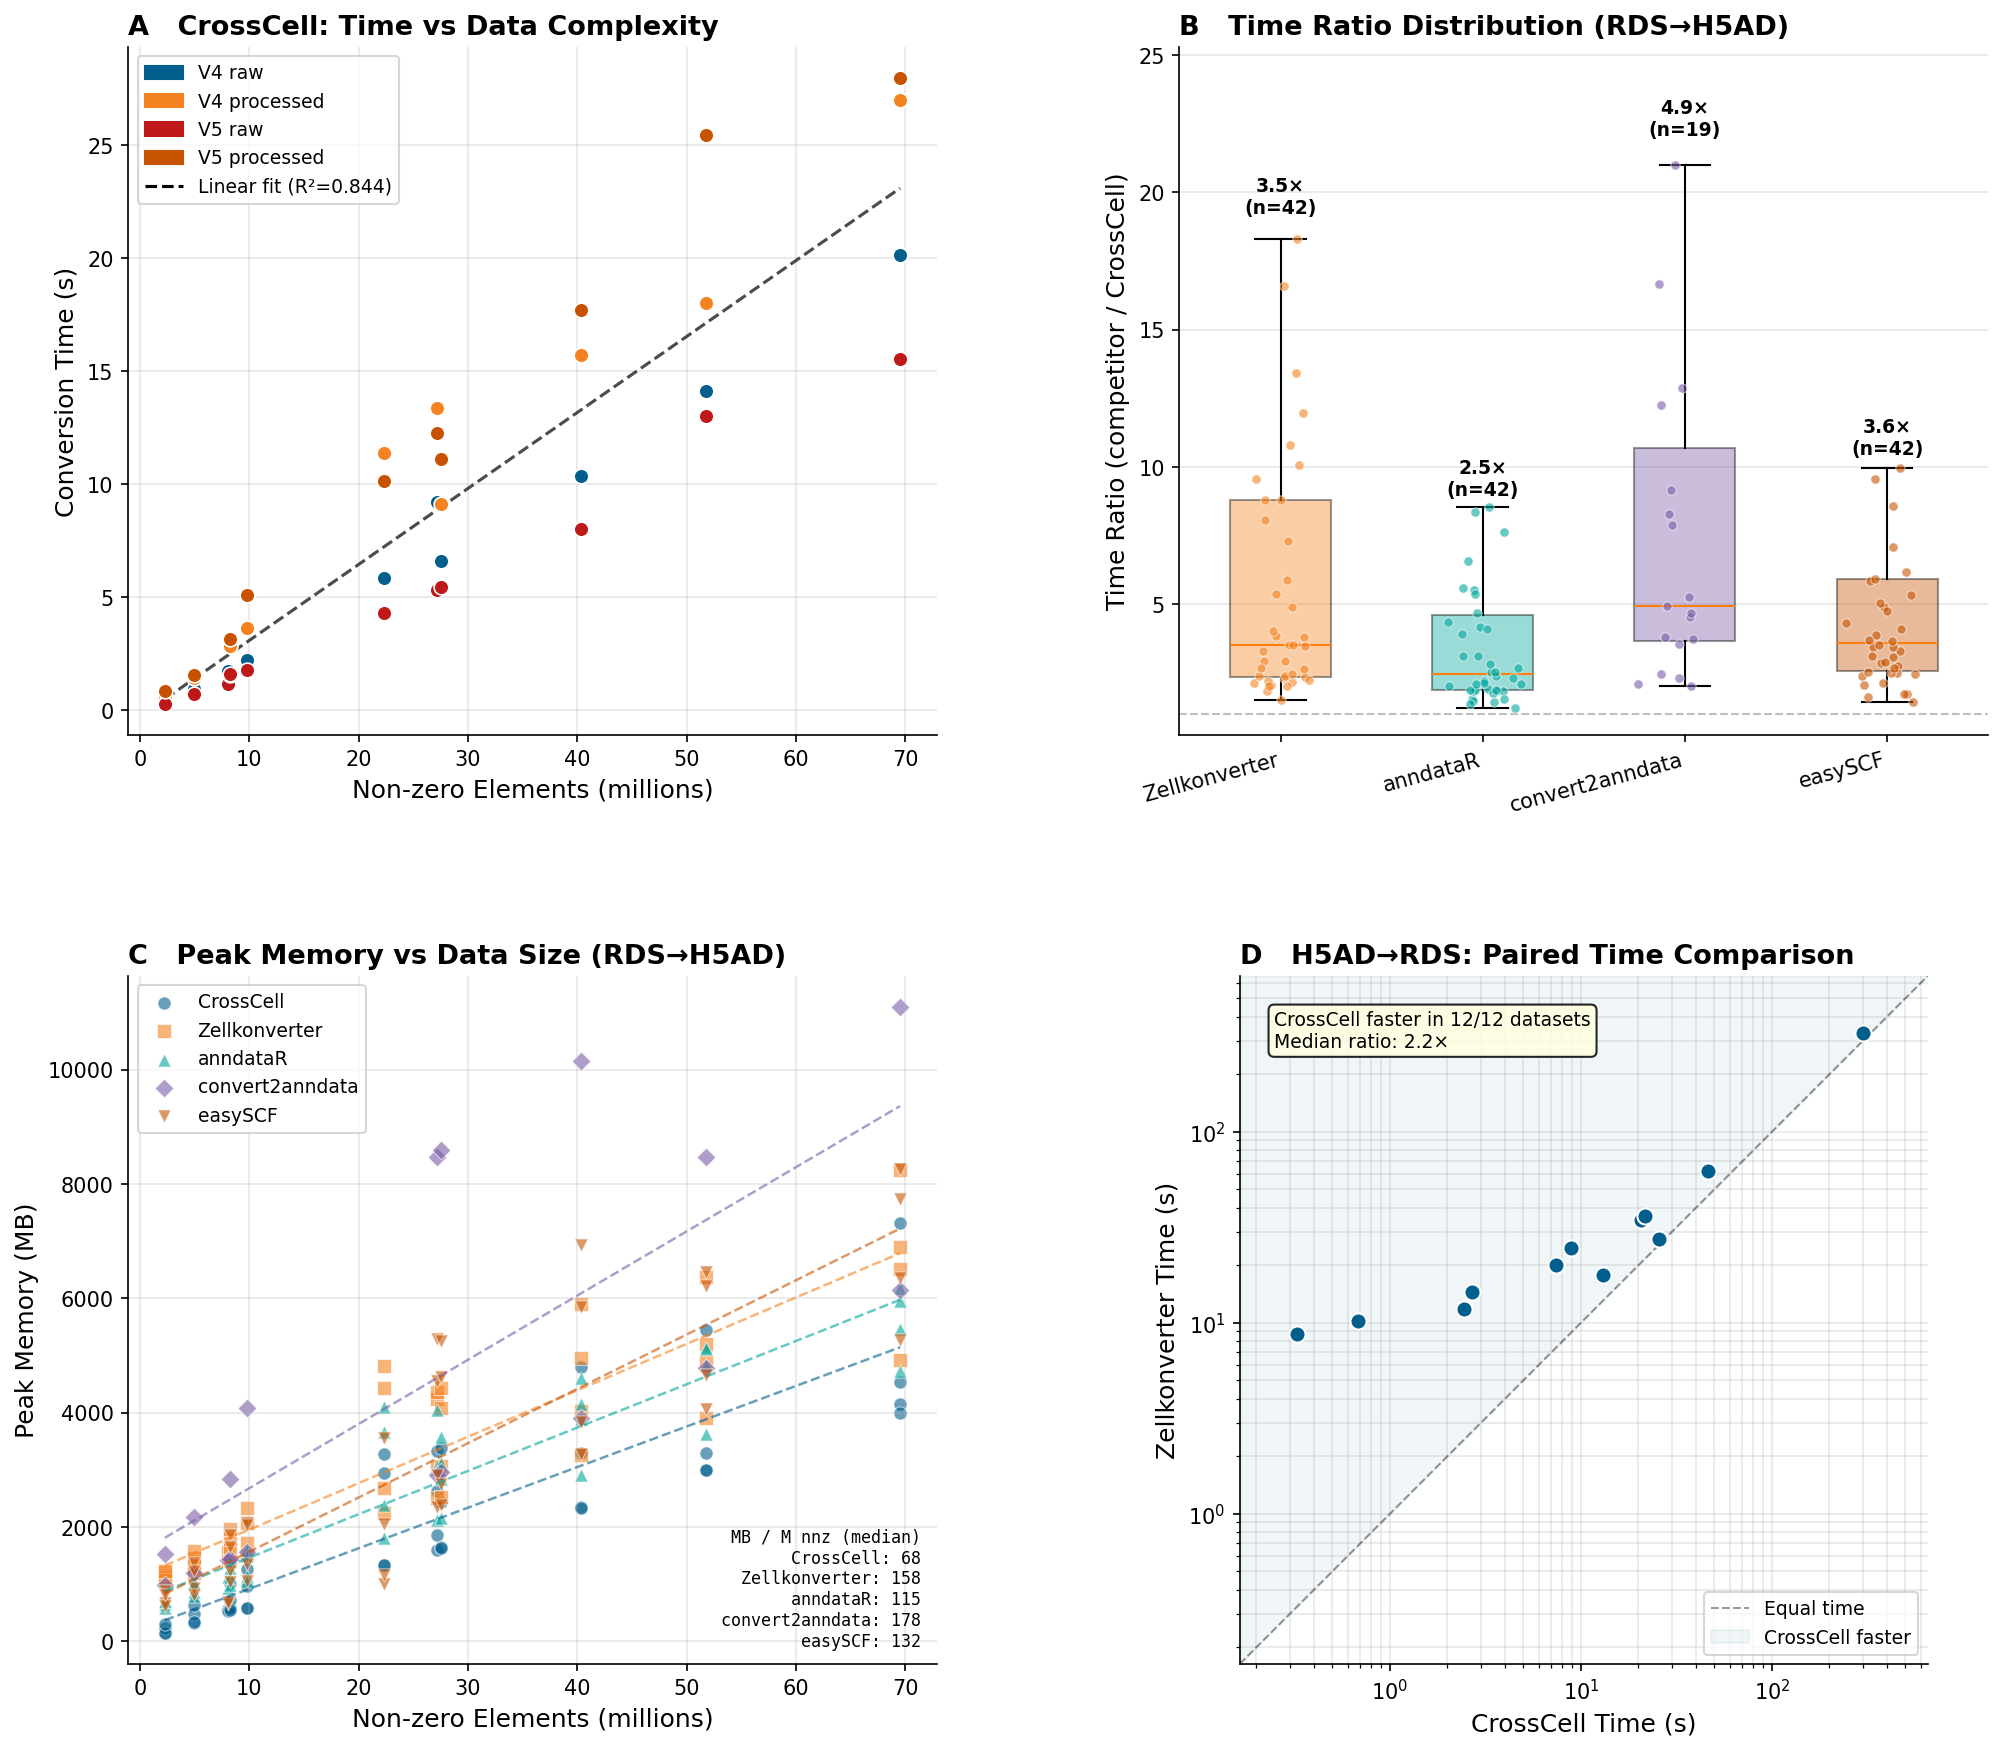

In [7]:
# ── Combined Figure: Panels A, B, C, D ──
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# ── Shared style ──
LABEL_SIZE = 12
TITLE_SIZE = 13
TICK_SIZE = 10
LEGEND_SIZE = 9

# ============================================================
# Panel A: CrossCell Time vs nnz (scatter + linear fit)
# ============================================================
ax_a = fig.add_subplot(gs[0, 0])

cat_colors = {'V4 raw': '#025e8d', 'V4 processed': '#f58220',
              'V5 raw': '#be1818', 'V5 processed': '#c75301'}

for _, row in cc_r2h.iterrows():
    cat = f'{row.get("seurat_version", "V5")} {row.get("type", "raw")}'
    color = cat_colors.get(cat, '#999')
    ax_a.scatter(row['nnz'] / 1e6,
                 row['conversion_time_seconds'], s=50, c=color, edgecolor='white',
                 linewidth=0.8, zorder=3)

x_vals = (cc_r2h['nnz'] / 1e6).values
y_vals = cc_r2h['conversion_time_seconds'].values
slope, intercept, r_value, _, _ = stats.linregress(x_vals, y_vals)
x_fit = np.linspace(x_vals.min(), x_vals.max(), 100)
ax_a.plot(x_fit, slope * x_fit + intercept, 'k--', linewidth=1.5, alpha=0.7)

patches_a = [mpatches.Patch(color=c, label=l) for l, c in cat_colors.items()]
patches_a.append(plt.Line2D([0],[0], color='k', linestyle='--',
                             label=f'Linear fit (R²={r_value**2:.3f})'))
ax_a.legend(handles=patches_a, loc='upper left', fontsize=LEGEND_SIZE)
ax_a.set_xlabel('Non-zero Elements (millions)', fontsize=LABEL_SIZE)
ax_a.set_ylabel('Conversion Time (s)', fontsize=LABEL_SIZE)
ax_a.set_title('A   CrossCell: Time vs Data Complexity', fontweight='bold',
               loc='left', fontsize=TITLE_SIZE)
ax_a.tick_params(labelsize=TICK_SIZE)
ax_a.grid(alpha=0.3)
ax_a.spines['top'].set_visible(False)
ax_a.spines['right'].set_visible(False)

# ============================================================
# Panel B: Time Ratio Distribution (box + jitter)
# ============================================================
ax_b = fig.add_subplot(gs[0, 1])

competitors = ['Zellkonverter', 'anndataR', 'convert2anndata', 'easySCF']
speedup_data = []
medians = []

for tool in competitors:
    if tool not in tool_dfs:
        speedup_data.append([])
        medians.append((tool, 0, 0))
        continue
    df_t = tool_dfs[tool]
    df_t_r2h = df_t[(df_t['direction'] == 'rds_to_h5ad') & (df_t['status'] == 'success')]
    merged = cc_r2h.merge(df_t_r2h[['test_id', 'conversion_time_seconds']],
                          on='test_id', suffixes=('_cc', '_other'), how='inner')
    if len(merged) > 0:
        sp = merged['conversion_time_seconds_other'] / merged['conversion_time_seconds_cc']
        speedup_data.append(sp.values)
        medians.append((tool, sp.median(), len(merged)))
    else:
        speedup_data.append([])
        medians.append((tool, 0, 0))

positions = np.arange(len(competitors))
bp = ax_b.boxplot(speedup_data, positions=positions, widths=0.5,
                  patch_artist=True, showfliers=False)

for i, (patch, tool) in enumerate(zip(bp['boxes'], competitors)):
    color = COLORS.get(tool, '#999')
    patch.set_facecolor(color)
    patch.set_alpha(0.4)
    # Jitter — only draw points within whisker range (no outliers)
    if len(speedup_data[i]) > 0:
        whisker_lo = bp['whiskers'][2 * i].get_ydata()[1]
        whisker_hi = bp['whiskers'][2 * i + 1].get_ydata()[1]
        mask = (speedup_data[i] >= whisker_lo) & (speedup_data[i] <= whisker_hi)
        pts = speedup_data[i][mask]
        jitter = np.random.normal(0, 0.08, len(pts))
        ax_b.scatter(positions[i] + jitter, pts, s=20, c=color,
                     alpha=0.6, edgecolor='white', linewidth=0.5, zorder=3)

ax_b.axhline(y=1, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax_b.set_xticks(positions)
ax_b.set_xticklabels(competitors, rotation=15, ha='right', fontsize=TICK_SIZE)
ax_b.set_ylabel('Time Ratio (competitor / CrossCell)', fontsize=LABEL_SIZE)

for tool, med, n in medians:
    idx = competitors.index(tool)
    if med > 0 and len(speedup_data[idx]) > 0:
        whisker_hi = bp['whiskers'][2 * idx + 1].get_ydata()[1]
        ax_b.text(idx, whisker_hi * 1.05, f'{med:.1f}×\n(n={n})',
                  ha='center', fontsize=LEGEND_SIZE, fontweight='bold')

ax_b.set_title('B   Time Ratio Distribution (RDS\u2192H5AD)', fontweight='bold',
               loc='left', fontsize=TITLE_SIZE)
# Add top margin so annotations don't overlap title
ymin_b, ymax_b = ax_b.get_ylim()
ax_b.set_ylim(ymin_b, ymax_b * 1.15)
ax_b.tick_params(labelsize=TICK_SIZE)
ax_b.grid(axis='y', alpha=0.3)
ax_b.spines['top'].set_visible(False)
ax_b.spines['right'].set_visible(False)

# ============================================================
# Panel C: Peak Memory vs nnz (multi-tool scatter)
# ============================================================
ax_c = fig.add_subplot(gs[1, 0])

markers = {'CrossCell': 'o', 'Zellkonverter': 's', 'anndataR': '^',
           'convert2anndata': 'D', 'easySCF': 'v'}

for tool_name, df_t in tool_dfs.items():
    df_ok = df_t[(df_t['direction'] == 'rds_to_h5ad') & (df_t['status'] == 'success')]
    if len(df_ok) == 0 or 'peak_memory_mb' not in df_ok.columns or 'nnz' not in df_ok.columns:
        continue
    x = df_ok['nnz'] / 1e6
    y = df_ok['peak_memory_mb']
    color = COLORS.get(tool_name, '#999')
    ax_c.scatter(x, y, s=40, alpha=0.6,
                 color=color, marker=markers.get(tool_name, 'o'),
                 label=tool_name, edgecolor='white', linewidth=0.5)
    # Linear fit line
    if len(x) >= 3:
        slope, intercept, r_val, _, _ = stats.linregress(x.values, y.values)
        x_fit = np.linspace(x.min(), x.max(), 50)
        ax_c.plot(x_fit, slope * x_fit + intercept, color=color, linestyle='--',
                  linewidth=1.2, alpha=0.6)


# Annotate memory efficiency (MB per million nnz)
eff_lines = []
for tool_name2, df_t2 in tool_dfs.items():
    df_ok2 = df_t2[(df_t2['direction'] == 'rds_to_h5ad') & (df_t2['status'] == 'success')]
    if len(df_ok2) == 0 or 'peak_memory_mb' not in df_ok2.columns or 'nnz' not in df_ok2.columns:
        continue
    eff = df_ok2['peak_memory_mb'] / (df_ok2['nnz'] / 1e6)
    eff_lines.append(f"{tool_name2}: {eff.median():.0f}")
eff_text = "MB / M nnz (median)\n" + "\n".join(eff_lines)
ax_c.text(0.98, 0.02, eff_text, transform=ax_c.transAxes,
        fontsize=8, ha='right', va='bottom', family='monospace')

ax_c.set_xlabel('Non-zero Elements (millions)', fontsize=LABEL_SIZE)
ax_c.set_ylabel('Peak Memory (MB)', fontsize=LABEL_SIZE)
ax_c.set_title('C   Peak Memory vs Data Size (RDS→H5AD)', fontweight='bold',
               loc='left', fontsize=TITLE_SIZE)
ax_c.legend(loc='upper left', fontsize=LEGEND_SIZE)
ax_c.tick_params(labelsize=TICK_SIZE)
ax_c.grid(alpha=0.3)
ax_c.spines['top'].set_visible(False)
ax_c.spines['right'].set_visible(False)

# ============================================================
# Panel D: H5AD→RDS Paired Time Comparison (CrossCell vs Zellkonverter)
# ============================================================
ax_d = fig.add_subplot(gs[1, 1])

cc_h2r = tool_dfs['CrossCell']
cc_h2r = cc_h2r[(cc_h2r['direction'] == 'h5ad_to_rds') & (cc_h2r['status'] == 'success')].copy()

zk_h2r = tool_dfs.get('Zellkonverter', pd.DataFrame())
if len(zk_h2r) > 0:
    zk_h2r = zk_h2r[(zk_h2r['direction'] == 'h5ad_to_rds') & (zk_h2r['status'] == 'success')].copy()

merged_d = cc_h2r[['test_id', 'conversion_time_seconds']].merge(
    zk_h2r[['test_id', 'conversion_time_seconds']],
    on='test_id', suffixes=('_cc', '_zk'), how='inner')

ax_d.scatter(merged_d['conversion_time_seconds_cc'], merged_d['conversion_time_seconds_zk'],
             s=60, c='#025e8d', edgecolor='white', linewidth=1, zorder=3)

lo_d = min(merged_d['conversion_time_seconds_cc'].min(), merged_d['conversion_time_seconds_zk'].min()) * 0.5
hi_d = max(merged_d['conversion_time_seconds_cc'].max(), merged_d['conversion_time_seconds_zk'].max()) * 2.0
ax_d.plot([lo_d, hi_d], [lo_d, hi_d], 'k--', linewidth=1, alpha=0.4, label='Equal time')

ax_d.fill_between([lo_d, hi_d], [lo_d, hi_d], [hi_d, hi_d],
                  alpha=0.06, color='#025e8d', label='CrossCell faster')

ax_d.set_xscale('log')
ax_d.set_yscale('log')
ax_d.set_xlim(lo_d, hi_d)
ax_d.set_ylim(lo_d, hi_d)
ax_d.set_aspect('equal')

median_ratio_d = (merged_d['conversion_time_seconds_zk'] / merged_d['conversion_time_seconds_cc']).median()
n_faster_d = (merged_d['conversion_time_seconds_cc'] < merged_d['conversion_time_seconds_zk']).sum()
ax_d.text(0.05, 0.95,
          f'CrossCell faster in {n_faster_d}/{len(merged_d)} datasets\nMedian ratio: {median_ratio_d:.1f}\u00d7',
          transform=ax_d.transAxes, fontsize=LEGEND_SIZE, va='top',
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.85))

ax_d.set_xlabel('CrossCell Time (s)', fontsize=LABEL_SIZE)
ax_d.set_ylabel('Zellkonverter Time (s)', fontsize=LABEL_SIZE)
ax_d.set_title('D   H5AD\u2192RDS: Paired Time Comparison', fontweight='bold',
               loc='left', fontsize=TITLE_SIZE)
ax_d.legend(loc='lower right', fontsize=LEGEND_SIZE)
ax_d.tick_params(labelsize=TICK_SIZE)
ax_d.grid(alpha=0.3, which='both')
ax_d.spines['top'].set_visible(False)
ax_d.spines['right'].set_visible(False)

plt.savefig(FIGURES_DIR / 'fig3_combined.pdf')
plt.savefig(FIGURES_DIR / 'fig3_combined.png')
print('Saved fig3_combined')
plt.show()